In [1]:
import kagglehub, os, glob
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [2]:
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [3]:
image_paths = {os.path.splitext(os.path.basename(p))[0]: p
               for p in glob.glob(os.path.join(path, "**", "*.jpg"), recursive=True)}
print("picture numbers:", len(image_paths))

picture numbers: 10015


In [4]:
df = pd.read_csv(os.path.join(path, "HAM10000_metadata.csv"))
df["path"] = df["image_id"].map(image_paths)
df = df.dropna(subset=["path"])

classes = sorted(df["dx"].unique())
print(classes)
print(df["dx"].value_counts())

['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [5]:
IMG_SIZE = 224
BATCH = 32
class_to_idx = {c: i for i, c in enumerate(classes)}
df["label"] = df["dx"].map(class_to_idx)

In [6]:
lesions = df.drop_duplicates("lesion_id")
train_les, val_les = train_test_split(lesions["lesion_id"], test_size=0.2,
                                      stratify=lesions["label"], random_state=42)
train_df = df[df["lesion_id"].isin(train_les)]
val_df = df[df["lesion_id"].isin(val_les)]

In [7]:
def load(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return img, label

def make_ds(d, train=False):
    ds = tf.data.Dataset.from_tensor_slices((d["path"].values, d["label"].values))
    ds = ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)
    if train:
        ds = ds.shuffle(2000)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_df, True)
val_ds = make_ds(val_df)

In [8]:
base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet")
base.trainable = False

inputs = layers.Input((IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(classes), activation="softmax")(x)
model = models.Model(inputs, outputs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [9]:
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [10]:
weights = compute_class_weight("balanced", classes=np.arange(len(classes)), y=train_df["label"])
class_weight = dict(enumerate(np.sqrt(weights)))
print(class_weight)

{0: np.float64(2.0792907768686155), 1: np.float64(1.6635581777936328), 2: np.float64(1.1403816224631251), 3: np.float64(3.6289295557855428), 4: np.float64(1.1314272815941442), 5: np.float64(0.4619892930325657), 6: np.float64(3.2273184558677217)}


In [11]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7),
]

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 105s 296ms/step - accuracy: 0.6998 - loss: 0.9947 - val_accuracy: 0.6436 - val_loss: 1.1532
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 220ms/step - accuracy: 0.7511 - loss: 0.8313 - val_accuracy: 0.6556 - val_loss: 1.1320
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 216ms/step - accuracy: 0.7702 - loss: 0.7651 - val_accuracy: 0.6917 - val_loss: 0.9748
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 72s 182ms/step - accuracy: 0.7854 - loss: 0.6976 - val_accuracy: 0.6762 - val_loss: 1.0721
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 83s 182ms/step - accuracy: 0.7910 - loss: 0.6745 - val_accuracy: 0.6942 - val_loss: 1.0079
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 222ms/step - accuracy: 0.8050 - loss: 0.6190 - val_accuracy: 0.6932 - val_loss: 1.0272
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 55s 178ms/step - accuracy: 0.8052 - loss: 0.6077 - val_accuracy: 0.7028 - val_loss: 0.9487
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 56s 180ms/step - accuracy: 0.8071 - loss: 

In [13]:
base.trainable = True
for layer in base.layers[:-60]:
    layer.trainable = False
for layer in base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history2 = model.fit(train_ds, validation_data=val_ds, epochs=25,
                     class_weight=class_weight, callbacks=callbacks)

Epoch 1/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 90s 255ms/step - accuracy: 0.7603 - loss: 0.7778 - val_accuracy: 0.6802 - val_loss: 0.9723 - learning_rate: 1.0000e-04
Epoch 2/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 56s 182ms/step - accuracy: 0.7832 - loss: 0.6786 - val_accuracy: 0.6461 - val_loss: 1.0180 - learning_rate: 1.0000e-04
Epoch 3/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 57s 187ms/step - accuracy: 0.8158 - loss: 0.5892 - val_accuracy: 0.6526 - val_loss: 0.9846 - learning_rate: 1.0000e-04
Epoch 4/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 81s 182ms/step - accuracy: 0.8305 - loss: 0.5235 - val_accuracy: 0.7083 - val_loss: 0.8718 - learning_rate: 3.0000e-05
Epoch 5/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 82s 182ms/step - accuracy: 0.8468 - loss: 0.4655 - val_accuracy: 0.7188 - val_loss: 0.8705 - learning_rate: 3.0000e-05
Epoch 6/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 93s 225ms/step - accuracy: 0.8483 - loss: 0.4454 - val_accuracy: 0.7183 - val_loss: 0.8283 - learning_rate: 3.0000e-05
Epoch 7/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 56s 18

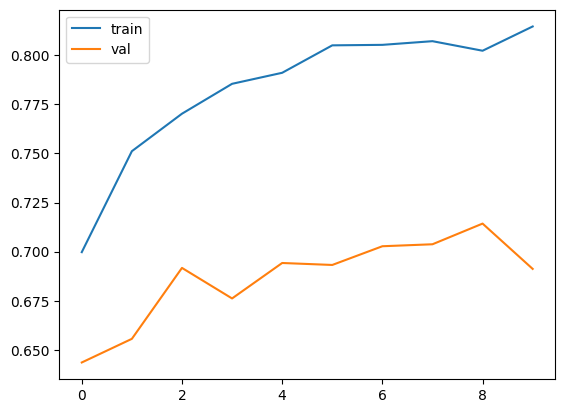

63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 222ms/step
              precision    recall  f1-score   support

       akiec       0.26      0.73      0.38        62
         bcc       0.75      0.33      0.46       100
         bkl       0.84      0.17      0.29       218
          df       0.71      0.36      0.48        28
         mel       0.67      0.13      0.22       218
          nv       0.80      0.98      0.88      1337
        vasc       0.71      0.62      0.67        32

    accuracy                           0.74      1995
   macro avg       0.68      0.47      0.48      1995
weighted avg       0.77      0.74      0.70      1995



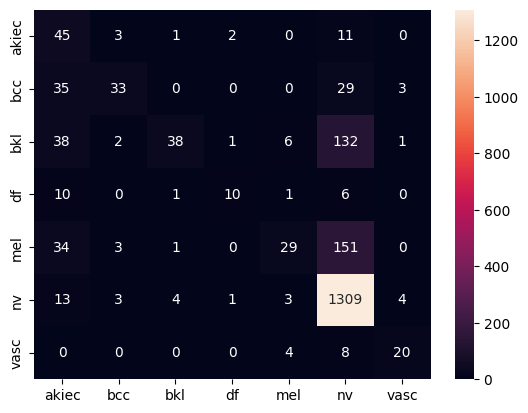

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.legend(); plt.show()

y_true = np.concatenate([y.numpy() for _, y in val_ds])
y_pred = np.argmax(model.predict(val_ds), axis=1)
print(classification_report(y_true, y_pred, target_names=classes))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt="d",
            xticklabels=classes, yticklabels=classes)
plt.show()

Saving Melanoma.jpg to Melanoma.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


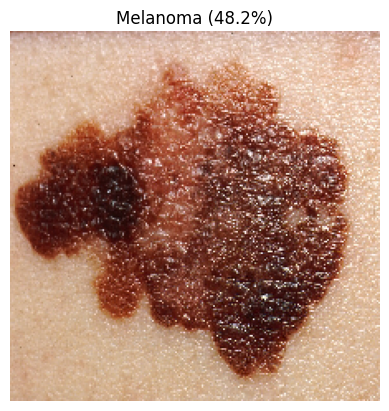

Melanoma: 48.2%
Melanocytic nevus : 37.7%
Benign keratosis: 11.8%


In [17]:
from google.colab import files
from tensorflow.keras.preprocessing import image

names = {
    "akiec": "Actinic keratosis",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevus ",
    "vasc": "Vascular lesion",
}

uploaded = files.upload()
for fn in uploaded:
    img = image.load_img(fn, target_size=(IMG_SIZE, IMG_SIZE))
    arr = np.expand_dims(image.img_to_array(img), 0)
    probs = model.predict(arr)[0]
    top = np.argsort(probs)[::-1][:3]
    plt.imshow(img); plt.axis("off")
    plt.title(f"{names[classes[top[0]]]} ({probs[top[0]]*100:.1f}%)"); plt.show()
    for i in top:
        print(f"{names[classes[i]]}: {probs[i]*100:.1f}%")